#### Load packages, set home directory

In [1]:
def mask_to_catchment(cube, catchment):

    catchment_proj = catchment.to_crs(epsg=27700)
    
    # Extract coordinates
    x = cube.coord('projection_x_coordinate').points
    y = cube.coord('projection_y_coordinate').points
    
    # Create 2D meshgrid of coordinates
    xx, yy = np.meshgrid(x, y)
    
    # Flatten coordinates
    points = np.vstack((xx.ravel(), yy.ravel())).T
    
    # Get catchment geometry
    catchment_geom = catchment_proj.geometry.iloc[0]
    
    # Test which grid cells are inside catchment
    mask = np.array([catchment_geom.contains(Point(pt)) for pt in points])
    
    # Reshape to grid
    mask = mask.reshape(len(y), len(x))
    return mask

# Function to convert a cftime object to string
def cft_to_string(cfttime_obj):
    """
    Convert a cftime.Datetime360Day (or other CFTime) object to 'YYYY-MM-DD' string
    """
    # Handle PartialDateTime or cftime
    try:
        year = str(cfttime_obj.year)
        month = str(cfttime_obj.month).zfill(2)
        day = str(cfttime_obj.day).zfill(2)
        return f"{year}-{month}-{day}"
    except AttributeError:
        return None  # in case it's missing or invalid

In [3]:
import iris
iris.FUTURE.date_microseconds = True
# from iris.warnings import IrisCfNonSpanningVarWarning
import warnings
warnings.filterwarnings("ignore", message=".*ensemble_member_id.*")
import iris.plot as iplt
import iris.quickplot as qplt
import iris.coord_systems as cs
import iris.coord_categorisation as icc
import iris.analysis
# from iris.coord_systems import OSGB
import geopandas as gpd
import os
import matplotlib.pyplot as plt
import glob as sir_globington_the_file_gatherer
import pandas as pd
import numpy as np
import contextily as ctx
from shapely.geometry import Point, Polygon, box, MultiPolygon
from shapely import vectorized, contains
from shapely.ops import unary_union
from shapely import intersects
import time
import cftime
import datetime
import cartopy.crs as ccrs
from scipy.ndimage import label, generate_binary_structure
import pickle

rainfalldir ='/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/01/'
# os.chdir(homedir)

catchments = gpd.read_file("/scratch/hydro4/users/kv25483/FutureFlood/Data/NewcastleExample/catchment_identifier/hyd_areas_GB_with_subcatchments.shp")
newcastle = catchments[catchments['HA_NUM'] == "23"]
catchment_poly = newcastle.geometry[60]

In [125]:
FLOOD_DIR = "/scratch/hydro5/users/la17355/FUTURE-FLOOD/Results/Pluvial/v4/5km_total/Ens01_23/30cm/"

flood_area = iris.load(FLOOD_DIR + "flooded_area_5km_total_Ens01_23_30cm.nc")[0]

bng = cs.OSGB()
flood_area.coord('projection_x_coordinate').coord_system = bng
flood_area.coord('projection_y_coordinate').coord_system = bng

flood_area.coord('projection_x_coordinate').guess_bounds()
flood_area.coord('projection_y_coordinate').guess_bounds()

flood_area = filter_closer_to_catchment(flood_area, catchment_poly, plot=False)

/home/kv25483/anaconda3/envs/futureflood/lib/python3.10/site-packages/iris/fileformats/cf.py:381: IrisCfMissingVarWarning: Missing CF-netCDF boundary variable 'projection_x_coordinate_bnds', referenced by netCDF variable 'projection_y_coordinate'
  warnings.warn(
/home/kv25483/anaconda3/envs/futureflood/lib/python3.10/site-packages/iris/__init__.py:680: FutureWarning: Ignoring a datum in netCDF load for consistency with existing behaviour. In a future version of Iris, this datum will be applied. To apply the datum when loading, use the iris.FUTURE.datum_support flag.
  cubes = _load_collection(uris, constraints, callback).combined().cubes()


### Get rainfall event csvs

In [4]:
home_dir = "/scratch/hydro4/users/" # kv25483/"
ncl_events = pd.read_csv(home_dir + "la17355/FUTURE-FLOOD/UKCP_rainfall_events/fixed_threshold_30mm_with_volume/Tyne(Northumberland)_01_full_events_with_event_nums.csv")

#### Get start and stop indices of the peak intensity relative to just this year
As it is the indices are stored relative to the full timeslice

### Get rainfall netCDF for relevant year


Processing event 1...
  Loading cube for year 1992...
  Building catchment mask (full_cell)...
Time elapsed: 19.0


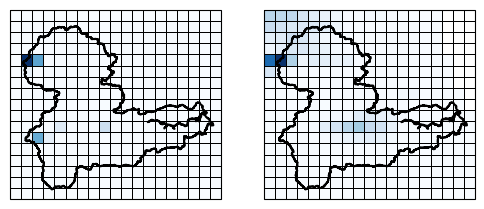

In [133]:
import warnings
import numpy as np
import pandas as pd
import iris
import iris.cube
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import iris.quickplot as qplt
from shapely.geometry import box
from shapely.strtree import STRtree
import time

# Suppress known harmless warnings
warnings.filterwarnings("ignore", message=".*ensemble_member_id.*")
warnings.filterwarnings("ignore", message=".*IrisCfNonSpanningVarWarning.*")
warnings.filterwarnings("ignore", message=".*IrisGuessBoundsWarning.*")

# ── Config ────────────────────────────────────────────────────────────────────
RAINFALLDIR = rainfalldir
METHOD = "full_cell"  # or "center_point"


# ── Event details ─────────────────────────────────────────────────────────────

def get_rainfall_event_details(ncl_events, event_num):
    """Extract metadata for a single event."""
    this_event = ncl_events[ncl_events['event_num'] == event_num].reset_index(drop=True)
    return {
        'event_num': event_num,
        'yr':        this_event['start_year'][0],
        'start_idx': this_event['start_indices'][0],
        'stop_idx':  this_event['stop_indices'][0],
    }


# ── Cube loading ──────────────────────────────────────────────────────────────

def get_rainfall_cube(yr):
    """Load and concatenate monthly rainfall cubes for the event year.
    Loads Dec of previous year + Jan-Nov of target year.
    """
    files = [
        f"{RAINFALLDIR}bc_pr_rcp85_land-cpm_uk_5km_01_1hr_{yr-1}1201-{yr-1}1230.nc"
    ]
    for m in range(1, 12):
        files.append(
            f"{RAINFALLDIR}bc_pr_rcp85_land-cpm_uk_5km_01_1hr_{yr}{m:02d}01-{yr}{m:02d}30.nc"
        )

    monthly_cubes = iris.cube.CubeList()
    for f in files:
        cube = iris.load(f)[1]
        cube.attributes = {}
        monthly_cubes.append(cube)

    return monthly_cubes.concatenate_cube()


# ── Mask building ─────────────────────────────────────────────────────────────

def filter_closer_to_catchment(cube, catchment_poly, plot=False):

    minx, miny, maxx, maxy = catchment_poly.bounds

    buffer = 2500  # metres

    constraint = iris.Constraint( projection_x_coordinate=lambda x: (minx - buffer) <= x <= (maxx + buffer),
        projection_y_coordinate=lambda y: (miny - buffer) <= y <= (maxy + buffer))

    sub_cube = cube.extract(constraint)
    
    if plot==True:
        fig, ax = plt.subplots(figsize=(6,6), subplot_kw={'projection': ccrs.OSGB()})
        qplt.pcolormesh(sub_cube[2], axes=ax, cmap = 'Blues', edgecolor='black', linewidth=0.5)
        newcastle.boundary.plot(ax=ax, color='black');
        
    return sub_cube


def build_mask(cube, catchment_poly, method="full_cell"):
    """Build a 2D boolean mask for the catchment polygon.
    Returns a (ny, nx) numpy array — True where inside catchment.
    Uses vectorised approaches for speed.
    """
    x = cube.coord('projection_x_coordinate').points
    y = cube.coord('projection_y_coordinate').points
    xx, yy = np.meshgrid(x, y)  # shape (ny, nx)

    if method == "center_point":
        # Vectorised point-in-polygon using shapely.vectorized
        from shapely.vectorized import contains
        mask = contains(catchment_poly, xx.ravel(), yy.ravel()).reshape(xx.shape)

    elif method == "full_cell":
        # Build all cell boxes, then use STRtree for fast intersection query
        dx, dy = x[1] - x[0], y[1] - y[0]
        cells = [
            box(xi - dx/2, yi - dy/2, xi + dx/2, yi + dy/2)
            for yi, xi in zip(yy.ravel(), xx.ravel())
        ]
        tree = STRtree(cells)
        hits = set(tree.query(catchment_poly, predicate='intersects'))
        mask = np.zeros(xx.size, dtype=bool)
        mask[list(hits)] = True
        mask = mask.reshape(xx.shape)

    else:
        raise ValueError("method must be 'center_point' or 'full_cell'")

    return mask  # (ny, nx) boolean array



def apply_mask_to_cube(cube, mask_2d):
    """Apply a prebuilt 2D boolean mask to a cube, returning a masked copy."""
    cube_masked = cube.copy()
    cube_masked.data = np.where(mask_2d[np.newaxis, :, :], cube.data, np.nan)
    return cube_masked


def plot_masked_cube(cube_masked, catchment_poly, event_num=None):
    """Plot the first timestep of a masked cube for a visual check."""
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': ccrs.OSGB()})

    # Fix coord system and guess bounds to avoid warnings
    for coord_name in ['projection_x_coordinate', 'projection_y_coordinate']:
        coord = cube_masked.coord(coord_name)
        coord.coord_system = iris.coord_systems.OSGB()
        if not coord.has_bounds():
            coord.guess_bounds()

    qplt.pcolormesh(cube_masked[0], axes=ax)
    minx, miny, maxx, maxy = catchment_poly.bounds
    ax.set_extent([minx, maxx, miny, maxy], crs=ccrs.OSGB())
    catchment_poly.boundary.plot(ax=ax, color='black')
    title = f"Masked cube - event {event_num} (first timestep)" if event_num else "Masked cube (first timestep)"
    plt.title(title)
    plt.show()


# ── Peak precipitation ────────────────────────────────────────────────────────

def find_max_precip_location(cube, mask_2d, start_idx, stop_idx):
    """Find peak precipitation location and time within the event window.
    Works directly on numpy arrays for speed rather than iris cube operations.
    """
    # Apply mask and extract event window as raw numpy array
    data = cube.data.copy().astype(float)
    data[:, ~mask_2d] = np.nan
    subset = data[start_idx:stop_idx, :, :]

    flat_index = np.nanargmax(subset)
    t_local, y_idx, x_idx = np.unravel_index(flat_index, subset.shape)

    return {
        'max_precip': subset[t_local, y_idx, x_idx],
        't_global':   t_local + start_idx,
        'x_idx':      int(x_idx),
        'y_idx':      int(y_idx),
        'x_coord':    cube.coord('projection_x_coordinate').points[x_idx],
        'y_coord':    cube.coord('projection_y_coordinate').points[y_idx],
    }


def find_temporal_profile(cube, details, peak, plot):
    # Extract event time series
    ts = cube[details['start_idx']:details['stop_idx'], peak['y_idx'], peak['x_idx']]
    
    times = ts.coord('yyyymmddhh').points.astype(int)
    values = ts.data

    # Convert to datetime
    dt = pd.to_datetime(times.astype(str), format="%Y%m%d%H")
    
    df = pd.DataFrame({'times':dt, 'values':values})
    
    # Plot
    if plot == True:
        plt.figure(figsize=(8,4))
        plt.plot(dt, values, color='black')

        # Mark peak timestep
        rainfall_peak_time = cube.coord('yyyymmddhh').points[peak['t_global']]
        peak_dt = pd.to_datetime(str(int(rainfall_peak_time)), format="%Y%m%d%H")
        plt.axvline(peak_dt, linestyle='--', color = 'red', label='Peak timestep')

        # Format ticks
        plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H'))

        plt.xlabel("Date")
        plt.ylabel("Precipitation intensity (mm/hr)")
        plt.title("Rainfall at peak grid cell during event")
        plt.legend()

        plt.tight_layout()
        plt.show()

    return {'temporal_profile':df}

# ── Extra plotting of rainfall ─────────────────────────────────────────────────────────────────

def analyse_peak_event(cube_catchment, details, peak, threshold_level, diagonal=True, neighbourhood_size=1):
    """
    Analyse a single peak rainfall event.
    
    Parameters
    ----------
    cube_catchment    : Iris cube, dims [time, y, x]
    t_global          : int, timestep index of peak
    y_idx, x_idx      : int, grid indices of peak cell
    threshold_level   : float, e.g. 0.25 for 25% of peak
    diagonal          : bool, use diagonal connectivity for clustering
    neighbourhood_size: int, number of steps out for neighbourhood sum
                        (1 = 3x3, 2 = 5x5, etc.)
    
    Returns
    -------
    dict of metrics
    """
    peak_slice = cube_catchment[peak['t_global'], :, :]
    rain = peak_slice.data
    peak_value = rain[peak['y_idx'], peak['x_idx']]
    threshold = threshold_level * peak_value

    x = peak_slice.coord('projection_x_coordinate').points
    y = peak_slice.coord('projection_y_coordinate').points
    dx = x[1] - x[0]  # cell size in metres

    # --- Threshold mask ---
    mask = rain >= threshold
    total_above_threshold = int(np.sum(mask))

    # --- Connected cluster ---
    if not diagonal:
        labeled, num_features = label(mask)
    else:
        structure = generate_binary_structure(2, 2)
        labeled, num_features = label(mask, structure=structure)
    peak_label = labeled[peak['y_idx'], peak['x_idx']]
    cluster_mask = (labeled == peak_label)
    cluster_size = int(np.sum(cluster_mask)) - 1  # exclude peak cell

    # --- Neighbourhood sum ---
    n = neighbourhood_size
    y_min = max(0, peak['y_idx'] - n)
    y_max = min(rain.shape[0], peak['y_idx'] + n + 1)
    x_min = max(0, peak['x_idx'] - n)
    x_max = min(rain.shape[1], peak['x_idx'] + n + 1)
    neighbourhood = rain[y_min:y_max, x_min:x_max]
    neighbourhood_sum = float(np.sum(neighbourhood))
    neighbourhood_sum = float(np.sum(neighbourhood)) - float(peak_value)
    neighbourhood_cells = neighbourhood.size

    return {
        't_global'              : peak['t_global'],
        'y_idx'                 : peak['y_idx'],
        'x_idx'                 : peak['x_idx'],
        'peak_x_coord'          : float(x[peak['x_idx']]),
        'peak_y_coord'          : float(y[peak['y_idx']]),
        'peak_value'            : float(peak_value),
        'threshold_level'       : threshold_level,
        'threshold_value'       : float(threshold),
        'total_above_threshold' : total_above_threshold,
        'cluster_size'          : cluster_size,
        'neighbourhood_size'    : neighbourhood_size,
        'neighbourhood_cells'   : neighbourhood_cells,
        'neighbourhood_sum'     : neighbourhood_sum,
    }

def plot_peak_event(cube_catchment, details, peak, threshold_level, diagonal=True, catchment_poly=None,boundary_gdf=None):
    """
    Plot threshold and cluster outlines side by side for a single event.
    """
    peak_slice = cube_catchment[peak['t_global'], :, :]
    rain = peak_slice.data
    peak_value = rain[peak['y_idx'], peak['x_idx']]
    threshold = threshold_level * peak_value
    mask = rain >= threshold

    x = peak_slice.coord('projection_x_coordinate').points
    y = peak_slice.coord('projection_y_coordinate').points
    dx = x[1] - x[0]
    dy = y[1] - y[0]

    # --- Connected cluster ---
    if not diagonal:
        labeled, _ = label(mask)
    else:
        structure = generate_binary_structure(2, 2)
        labeled, _ = label(mask, structure=structure)
    peak_label = labeled[peak['y_idx'], peak['x_idx']]
    cluster_mask = (labeled == peak_label)

    def make_outline(bool_mask):
        ys_m, xs_m = np.where(bool_mask)
        cells = [box(x[xi]-dx/2, y[yi]-dy/2, x[xi]+dx/2, y[yi]+dy/2)
                 for yi, xi in zip(ys_m, xs_m)]
        shape = unary_union(cells)
        return shape.geoms if isinstance(shape, MultiPolygon) else [shape]

    threshold_polys = make_outline(mask)
    cluster_polys   = make_outline(cluster_mask)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6),
                             subplot_kw={'projection': ccrs.OSGB()})

    for ax, polys, colour, title in zip(
        axes,
        [threshold_polys, cluster_polys],
        ['darkgreen', 'orange'],
        [f'All cells above threshold ({threshold_level*100:.0f}% of peak)',
         f'Connected cluster only ({threshold_level*100:.0f}% of peak)']
    ):
        qplt.pcolormesh(peak_slice, axes=ax, cmap='Blues')

        for poly in polys:
            xs_p, ys_p = poly.exterior.xy
            ax.plot(xs_p, ys_p, color=colour, linewidth=3.5, transform=ccrs.OSGB())

        ax.scatter(x[peak['x_idx']], y[peak['y_idx']], color='red', s=20,
                   transform=ccrs.OSGB(), zorder=5)

        if catchment_poly is not None:
            buffer = 2000
            minx, miny, maxx, maxy = catchment_poly.bounds
            ax.set_extent([minx-buffer, maxx+buffer,
                           miny-buffer, maxy+buffer], crs=ccrs.OSGB())

        if boundary_gdf is not None:
            boundary_gdf.boundary.plot(ax=ax, color='black')

        ax.set_title(title)
    
    t_global = peak['t_global']
    plt.suptitle(f'Peak value: {peak_value:.2f} | Timestep: {t_global}')
    plt.tight_layout()
    plt.show()


# ── Main loop ─────────────────────────────────────────────────────────────────

def process_events(ncl_events, event_nums, catchment_poly, method=METHOD, plot=False):
    """
    Process a list of event numbers and return results as a list of dicts.

    Parameters
    ----------
    ncl_events     : pd.DataFrame   — full events table
    event_nums     : list[int]      — event numbers to process
    catchment_poly : shapely geom   — catchment polygon
    method         : str            — masking method: 'full_cell' or 'center_point'
    plot           : bool           — whether to plot each masked cube for checking

    Returns
    -------
    pd.DataFrame with one row per event
    """
    results = []

    # Caches — avoid reloading cubes or rebuilding masks unnecessarily
    cached_yr    = None
    cached_cube  = None
    cached_shape = None
    cached_mask  = None

    for event_num in event_nums:
        

        start = time.time()
        print(f"\nProcessing event {event_num}...")
        
        # Get details needed to subset the rainfall cube from the list of events
        details = get_rainfall_event_details(ncl_events, event_num)
        yr      = details['yr']

        # Only reload cube if year has changed
        if yr != cached_yr:
            print(f"  Loading cube for year {yr}...")
            cached_cube = get_rainfall_cube(yr)
            cached_cube = filter_closer_to_catchment(cached_cube, catchment_poly, plot=False)
            cached_yr   = yr
        else:
            print("It's the same year")

        # Only rebuild mask if grid shape has changed (e.g. different resolution files)
        if cached_shape is None or cached_cube.shape[1:] != cached_shape:
            print(f"  Building catchment mask ({method})...")
            cached_mask  = build_mask(cached_cube, catchment_poly, method)
            cached_shape = cached_cube.shape[1:]
        else:
            print(f"  Reusing catchment mask ({method})...")
        if plot:
            cube_masked = apply_mask_to_cube(cached_cube, cached_mask)
            plot_masked_cube(cube_masked, catchment_poly, event_num)

        #
        peak = find_max_precip_location(cached_cube, cached_mask, details['start_idx'], details['stop_idx'])
        
        # 
        temp_profile = find_temporal_profile(cached_cube, details, peak, plot = False)

        #
        threshold_level = 0.3
        test = analyse_peak_event(cached_cube, details, peak, threshold_level, diagonal=True, neighbourhood_size=1)
        
        # Plot the rainfall at the peak timestep
        # plot_peak_event(cached_cube, details, peak, threshold_level, diagonal=True, catchment_poly=catchment_poly, boundary_gdf=newcastle)
        
        # Get flood
        this_flood = flood_area[event_num-1, :,: ]
        
        # Plot
        fig, axs = plt.subplots(ncols=2, figsize=(6,6), subplot_kw={'projection': ccrs.OSGB()})
        iplt.pcolormesh(this_flood, axes=axs[0], cmap = 'Blues', edgecolor='black', linewidth=0.5)
        newcastle.boundary.plot(ax=axs[0], color='black');

        iplt.pcolormesh(cached_cube[peak['t_global']], axes=axs[1], cmap = 'Blues', edgecolor='black', linewidth=0.2)
        newcastle.boundary.plot(ax=axs[1], color='black');
        
        result = {**details, **peak, **temp_profile}
        results.append(result)

        # print(f"  Max precip : {peak['max_precip']:.2f}")
        # print(f"  Time index : {peak['t_global']}")
        # print(f"  Grid cell  : x={peak['x_idx']}, y={peak['y_idx']}")
        # print(f"  Coords     : easting={peak['x_coord']:.0f}, northing={peak['y_coord']:.0f}")
        
        end = time.time()
        print(f"Time elapsed: {round(end - start,1)}")

    return pd.DataFrame(results)


# ── Run ───────────────────────────────────────────────────────────────────────

if __name__ == "__main__":

    event_nums_to_process = list(ncl_events['event_num'].unique())
    event_nums_to_process = [1]

    results = process_events(
        ncl_events      = ncl_events,
        event_nums      = event_nums_to_process,
        catchment_poly  = catchment_poly,
        method          = "full_cell",
        plot            = False,)

    # Optionally convert to DataFrame
    results_df = pd.DataFrame(results)
    #print(results_df)     


In [123]:
# details = get_rainfall_event_details(ncl_events, event_num)
# details

In [122]:
# ncl_events

In [131]:
event_num

1

In [9]:
# one_timestep = cube_uk_1994[0,:,:]
# qplt.contourf(one_timestep)  # first time slice
# plt.gca().coastlines()

#### Find the spatial profile of the event at the timestep of the maximum

In [39]:
def analyse_peak_event(cube_catchment, details, peak, threshold_level, diagonal=True, neighbourhood_size=1):
    """
    Analyse a single peak rainfall event.
    
    Parameters
    ----------
    cube_catchment    : Iris cube, dims [time, y, x]
    t_global          : int, timestep index of peak
    y_idx, x_idx      : int, grid indices of peak cell
    threshold_level   : float, e.g. 0.25 for 25% of peak
    diagonal          : bool, use diagonal connectivity for clustering
    neighbourhood_size: int, number of steps out for neighbourhood sum
                        (1 = 3x3, 2 = 5x5, etc.)
    
    Returns
    -------
    dict of metrics
    """
    peak_slice = cube_catchment[peak['t_global'], :, :]
    rain = peak_slice.data
    peak_value = rain[peak['y_idx'], peak['x_idx']]
    threshold = threshold_level * peak_value

    x = peak_slice.coord('projection_x_coordinate').points
    y = peak_slice.coord('projection_y_coordinate').points
    dx = x[1] - x[0]  # cell size in metres

    # --- Threshold mask ---
    mask = rain >= threshold
    total_above_threshold = int(np.sum(mask))

    # --- Connected cluster ---
    if not diagonal:
        labeled, num_features = label(mask)
    else:
        structure = generate_binary_structure(2, 2)
        labeled, num_features = label(mask, structure=structure)
    peak_label = labeled[peak['y_idx'], peak['x_idx']]
    cluster_mask = (labeled == peak_label)
    cluster_size = int(np.sum(cluster_mask)) - 1  # exclude peak cell

    # --- Neighbourhood sum ---
    n = neighbourhood_size
    y_min = max(0, peak['y_idx'] - n)
    y_max = min(rain.shape[0], peak['y_idx'] + n + 1)
    x_min = max(0, peak['x_idx'] - n)
    x_max = min(rain.shape[1], peak['x_idx'] + n + 1)
    neighbourhood = rain[y_min:y_max, x_min:x_max]
    neighbourhood_sum = float(np.sum(neighbourhood))
    neighbourhood_sum = float(np.sum(neighbourhood)) - float(peak_value)
    neighbourhood_cells = neighbourhood.size

    return {
        't_global'              : peak['t_global'],
        'y_idx'                 : peak['y_idx'],
        'x_idx'                 : peak['x_idx'],
        'peak_x_coord'          : float(x[peak['x_idx']]),
        'peak_y_coord'          : float(y[peak['y_idx']]),
        'peak_value'            : float(peak_value),
        'threshold_level'       : threshold_level,
        'threshold_value'       : float(threshold),
        'total_above_threshold' : total_above_threshold,
        'cluster_size'          : cluster_size,
        'neighbourhood_size'    : neighbourhood_size,
        'neighbourhood_cells'   : neighbourhood_cells,
        'neighbourhood_sum'     : neighbourhood_sum,
    }

def plot_peak_event(cube_catchment, details, peak, threshold_level, diagonal=True, catchment_poly=None,boundary_gdf=None):
    """
    Plot threshold and cluster outlines side by side for a single event.
    """
    peak_slice = cube_catchment[peak['t_global'], :, :]
    rain = peak_slice.data
    peak_value = rain[peak['y_idx'], peak['x_idx']]
    threshold = threshold_level * peak_value
    mask = rain >= threshold

    x = peak_slice.coord('projection_x_coordinate').points
    y = peak_slice.coord('projection_y_coordinate').points
    dx = x[1] - x[0]
    dy = y[1] - y[0]

    # --- Connected cluster ---
    if not diagonal:
        labeled, _ = label(mask)
    else:
        structure = generate_binary_structure(2, 2)
        labeled, _ = label(mask, structure=structure)
    peak_label = labeled[peak['y_idx'], peak['x_idx']]
    cluster_mask = (labeled == peak_label)

    def make_outline(bool_mask):
        ys_m, xs_m = np.where(bool_mask)
        cells = [box(x[xi]-dx/2, y[yi]-dy/2, x[xi]+dx/2, y[yi]+dy/2)
                 for yi, xi in zip(ys_m, xs_m)]
        shape = unary_union(cells)
        return shape.geoms if isinstance(shape, MultiPolygon) else [shape]

    threshold_polys = make_outline(mask)
    cluster_polys   = make_outline(cluster_mask)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6),
                             subplot_kw={'projection': ccrs.OSGB()})

    for ax, polys, colour, title in zip(
        axes,
        [threshold_polys, cluster_polys],
        ['darkgreen', 'orange'],
        [f'All cells above threshold ({threshold_level*100:.0f}% of peak)',
         f'Connected cluster only ({threshold_level*100:.0f}% of peak)']
    ):
        qplt.pcolormesh(peak_slice, axes=ax, cmap='Blues')

        for poly in polys:
            xs_p, ys_p = poly.exterior.xy
            ax.plot(xs_p, ys_p, color=colour, linewidth=3.5, transform=ccrs.OSGB())

        ax.scatter(x[peak['x_idx']], y[peak['y_idx']], color='red', s=20,
                   transform=ccrs.OSGB(), zorder=5)

        if catchment_poly is not None:
            buffer = 2000
            minx, miny, maxx, maxy = catchment_poly.bounds
            ax.set_extent([minx-buffer, maxx+buffer,
                           miny-buffer, maxy+buffer], crs=ccrs.OSGB())

        if boundary_gdf is not None:
            boundary_gdf.boundary.plot(ax=ax, color='black')

        ax.set_title(title)
    
    t_global = peak['t_global']
    plt.suptitle(f'Peak value: {peak_value:.2f} | Timestep: {t_global}')
    plt.tight_layout()
    plt.show()

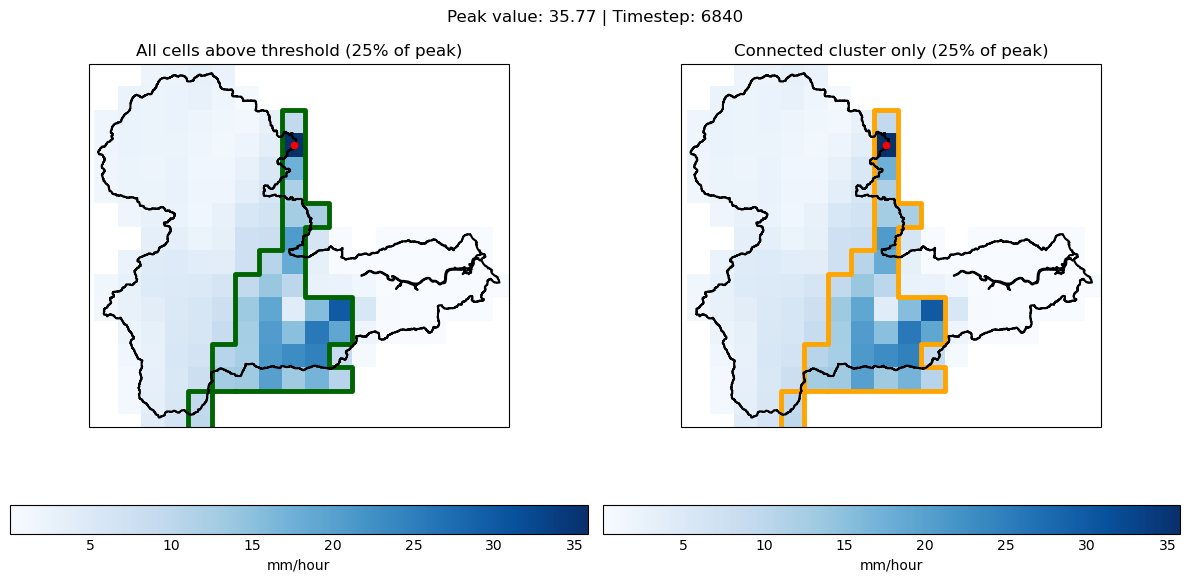

In [17]:
# Define your events — each is a dict of kwargs for analyse_peak_event
events = [
    dict(t_global=t_global, y_idx=y_idx, x_idx=x_idx, threshold_level=0.25),
#     dict(t_global=t2, y_idx=y2, x_idx=x2, threshold_level=0.25),
]

results = [analyse_peak_event(cube_catchment, **e) for e in events]
results_df = pd.DataFrame(results)

# Plot a specific event
plot_peak_event(cube_catchment, t_global=t_global, y_idx=y_idx, x_idx=x_idx,
                threshold_level=0.25, catchment_poly=catchment_poly,
                boundary_gdf=newcastle)

## Find soil moisture beneath the peak

Get one year soil moisture data

In [26]:
sm_dir = '/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/Ens_01/'
sm_one_yr = iris.load(sm_dir + f'r001i1p00000_{yr-1}1201-{yr}1130_mrso.nc')[0]

Get soil moisture just at the cell which had the peak value

In [27]:
sm_one_yr_at_max_cell = sm_one_yr[:, y_idx, x_idx]

Get the day of the peak rainfall event as a cftime.Datetime360Day object

In [28]:
time_coord = cube_catchment.coord('time')
t = time_coord.units.num2date(time_coord.points[t_global])
rainfall_peak_day = cftime.Datetime360Day(t.year, t.month, t.day)

Get the day of the rainfall event starting/stopping as a cftime.Datetime360Day object

In [29]:
rainfall_start_t = time_coord.units.num2date(time_coord.points[start_index])
rainfall_start_day = cftime.Datetime360Day(rainfall_start_t.year, rainfall_start_t.month, rainfall_start_t.day)

rainfall_stop_t = time_coord.units.num2date(time_coord.points[stop_index])
rainfall_stop_day = cftime.Datetime360Day(rainfall_stop_t.year, rainfall_stop_t.month, rainfall_stop_t.day)

Get soil moisture X days before and after rainfall peak at the peak grid cell

In [30]:
delta = datetime.timedelta(days=10)

start_time = rainfall_peak_day - delta
end_time = rainfall_peak_day + delta

subset = sm_one_yr_at_max_cell.extract(iris.Constraint(time=lambda t: start_time <= t.point <= end_time))

Create daily version of rainfall grid

In [31]:
# --- Rainfall at peak grid cell ---
rain_cell = cube_catchment[:, y_idx, x_idx]

# Add year/day_of_year coords for aggregation
icc.add_day_of_year(rain_cell, 'time')

# Aggregate to daily means
rain_daily = rain_cell.aggregated_by(['year','day_of_year'], iris.analysis.MEAN)

Get rainfall at peak grid cell before and after peak

In [32]:
# Extract 10 days before and after event
delta = datetime.timedelta(days=10)
window_start = rainfall_start_day - delta
window_end   = rainfall_stop_day + delta
rain_window = rain_daily.extract(iris.Constraint(time=lambda t: window_start <= t.point <= window_end))
rain_times = rain_window.coord('time').units.num2date(rain_window.coord('time').points)
rain_times_str = [t.strftime('%Y-%m-%d') for t in rain_times]
rain_values = rain_window.data

Plot

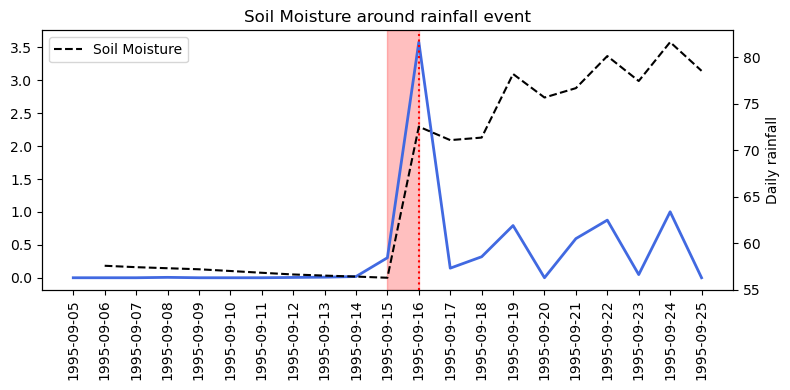

In [33]:
fig,ax1=plt.subplots(figsize=(8,4))

# Get formatted times
peak_str = rainfall_peak_day.strftime('%Y-%m-%d')
start_str = rainfall_start_day.strftime('%Y-%m-%d')
end_str = rainfall_stop_day.strftime('%Y-%m-%d')

# ------- Plot rainfall data (axis 1) -------
mask = ~np.isnan(rain_values)
ax1.plot(np.array(rain_times_str)[mask], rain_values[mask], linewidth=2, color='royalblue', label='Daily rainfall (peak cell)')

# Plot time of peak, and start and stop of event
ax1.axvline(peak_str, color='red', linestyle="dotted", label="Rainfall peak")
ax1.axvspan(start_str, end_str, color="red", alpha=0.25, label="Rainfall event")

ax1.tick_params(axis='x', rotation=90)

# ------- Plot soil moisture data (axis 2) -------
# Create secondary y-axis
ax2 = ax1.twinx()

# Get time values formatted for plotting
time_coord = subset.coord('time')
times = time_coord.units.num2date(time_coord.points)
times_str = [t.strftime('%Y-%m-%d') for t in times]
# Get 1D data array
values = subset.data

# Plot rainfall data
ax2.plot(times_str, values, color='black', linestyle='dashed', label="Soil Moisture")

ax2.set_ylabel("Soil Moisture")
ax2.set_title("Soil Moisture around rainfall event")

ax2.set_ylabel("Daily rainfall") 

plt.legend()
plt.tight_layout()
plt.show()

### Find mean soil moisture at that grid cell 1/3/5 days before peak 

In [34]:
n_days_ls = [2,3,4,5]
mean_sm_ls = []
for n_days in n_days_ls:
    delta = datetime.timedelta(days=n_days)
    start_time = rainfall_peak_day - delta
    end_time = rainfall_peak_day  # exclusive of the peak day itself

    # Subset using both bounds
    subset = sm_one_yr_at_max_cell.extract(
        iris.Constraint(time=lambda cell: start_time <= cell.point < end_time))

    # Compute mean soil moisture over those 3 days
    if n_days == 1:
        mean_sm = subset.data
    else:
        mean_sm = subset.collapsed('time', iris.analysis.MEAN)

    mean_sm_ls.append(mean_sm.data)

## Flood outcomes below the peak

In [41]:
iris.FUTURE.datum_support = True

In [99]:
event_num = rainfall_events_oneyr['event_num'][0]
event_num = event_num-1 

In [100]:
os.listdir("/scratch/hydro5/users/la17355/FUTURE-FLOOD/Results/Pluvial/v4/5km_total/Ens01_23/10cm/")
flood_area = iris.load("/scratch/hydro5/users/la17355/FUTURE-FLOOD/Results/Pluvial/v4/5km_total/Ens01_23/10cm/flooded_area_5km_total_Ens01_23_10cm.nc")[0]
flood_area_one_event = flood_area[event_num]
flood_area_one_event

flood_area_one_event.coord('projection_x_coordinate').guess_bounds()
flood_area_one_event.coord('projection_y_coordinate').guess_bounds()
bng = cs.OSGB()
flood_area_one_event.coord('projection_x_coordinate').coord_system = bng
flood_area_one_event.coord('projection_y_coordinate').coord_system = bng

/home/kv25483/anaconda3/envs/futureflood/lib/python3.10/site-packages/iris/fileformats/cf.py:381: IrisCfMissingVarWarning: Missing CF-netCDF boundary variable 'projection_x_coordinate_bnds', referenced by netCDF variable 'projection_y_coordinate'
  warnings.warn(


<iris 'Cube' of Total flooded area per 5km grid cell / (km2) (projection_y_coordinate: 244; projection_x_coordinate: 180)>

In [134]:
rain_cell = flood_area_one_event[y_idx, x_idx]
float(rain_cell.data)

NameError: name 'y_idx' is not defined

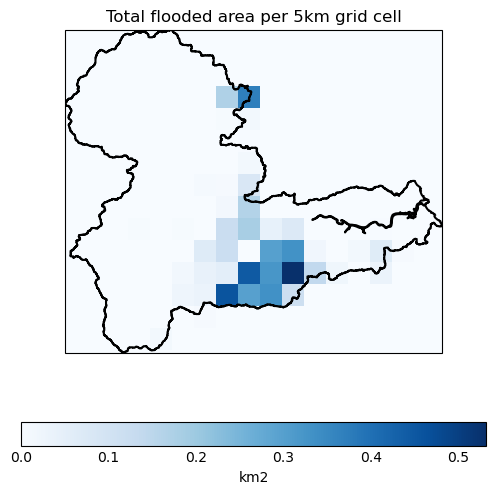

In [104]:
fig, ax = plt.subplots(figsize=(6,6), subplot_kw={'projection': ccrs.OSGB()})
qplt.pcolormesh(flood_area_one_event, axes=ax, cmap = 'Blues')

minx, miny, maxx, maxy = catchment_poly.bounds
ax.set_extent([minx, maxx, miny, maxy], crs=ccrs.OSGB())
newcastle.boundary.plot(ax=ax, color='black');

# plt.colorbar()
# plt.show()

In [ ]:
home_dir = "/scratch/hydro4/users/" # kv25483/"
ncl_events = pd.read_csv(home_dir + "la17355/FUTURE-FLOOD/UKCP_rainfall_events/fixed_threshold_30mm_with_volume/Tyne(Northumberland)_01_full_events_with_event_nums.csv")
rainfall_events_oneyr = ncl_events[ncl_events['start_year']==yr]
rainfall_events_oneyr = rainfall_events_oneyr.reset_index(drop=True)
rainfall_events_oneyr